<a href="https://colab.research.google.com/github/Ulml/claude_agent_system_komai/blob/claude%2Ftensor-product-model/Final_Canopy_app_validated_functions_global_w_sauvegarde.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validated functions

# Code

##Graph de réseau

#### Visualisation du Graph à partir de la matrice de contribution


--- Visualizing Graph: Graph Structure (4x4 Matrix T) (Using spring_layout) ---
Using spring_layout with k=0.400, iterations=75


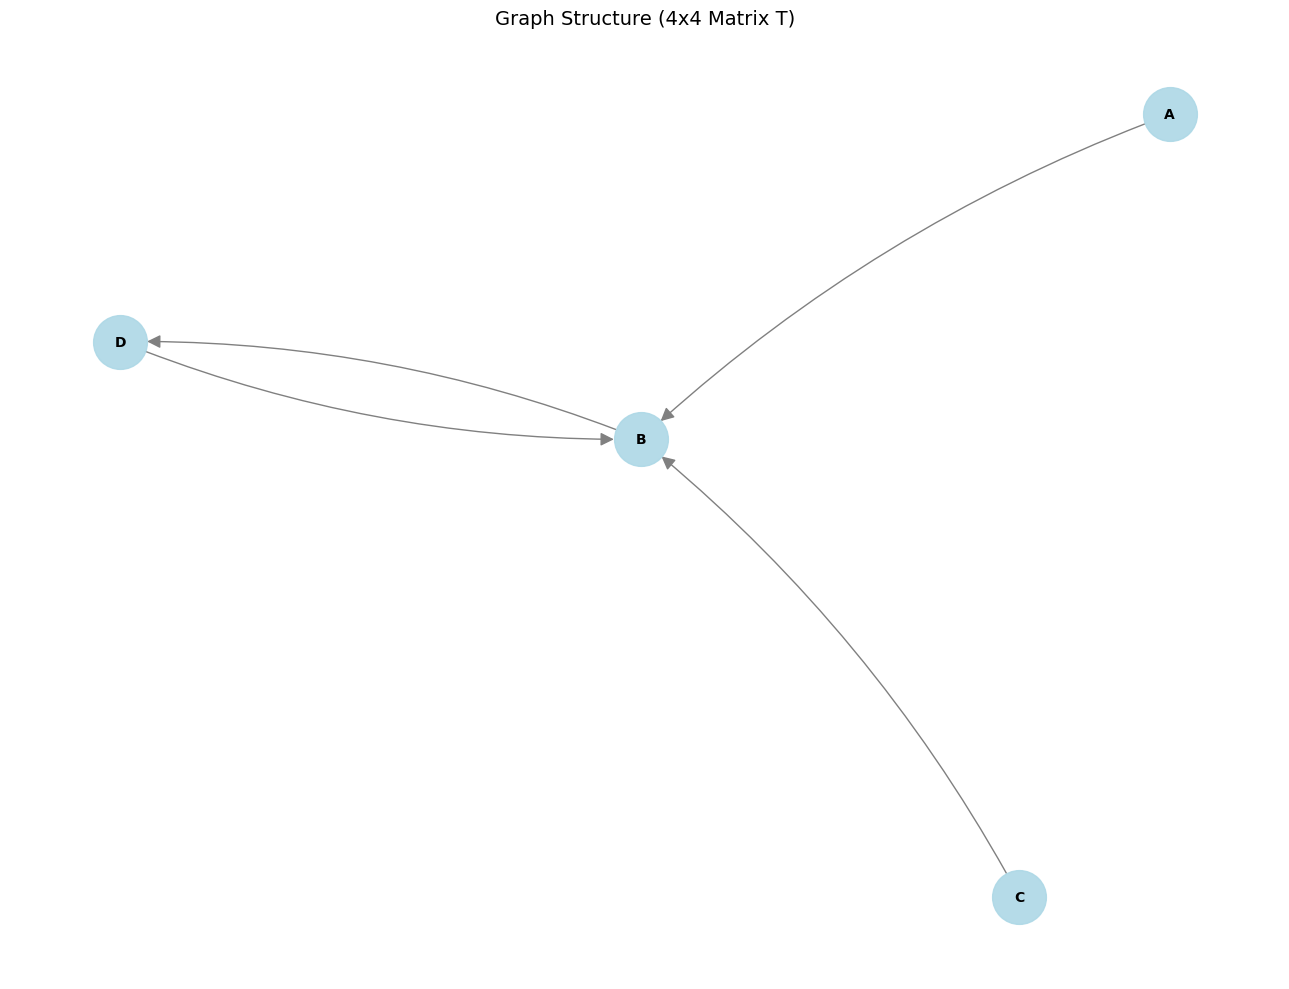


--- Visualizing Graph: Graph Structure (10x10 Matrix T) (Using spring_layout) ---
Using spring_layout with k=0.253, iterations=75


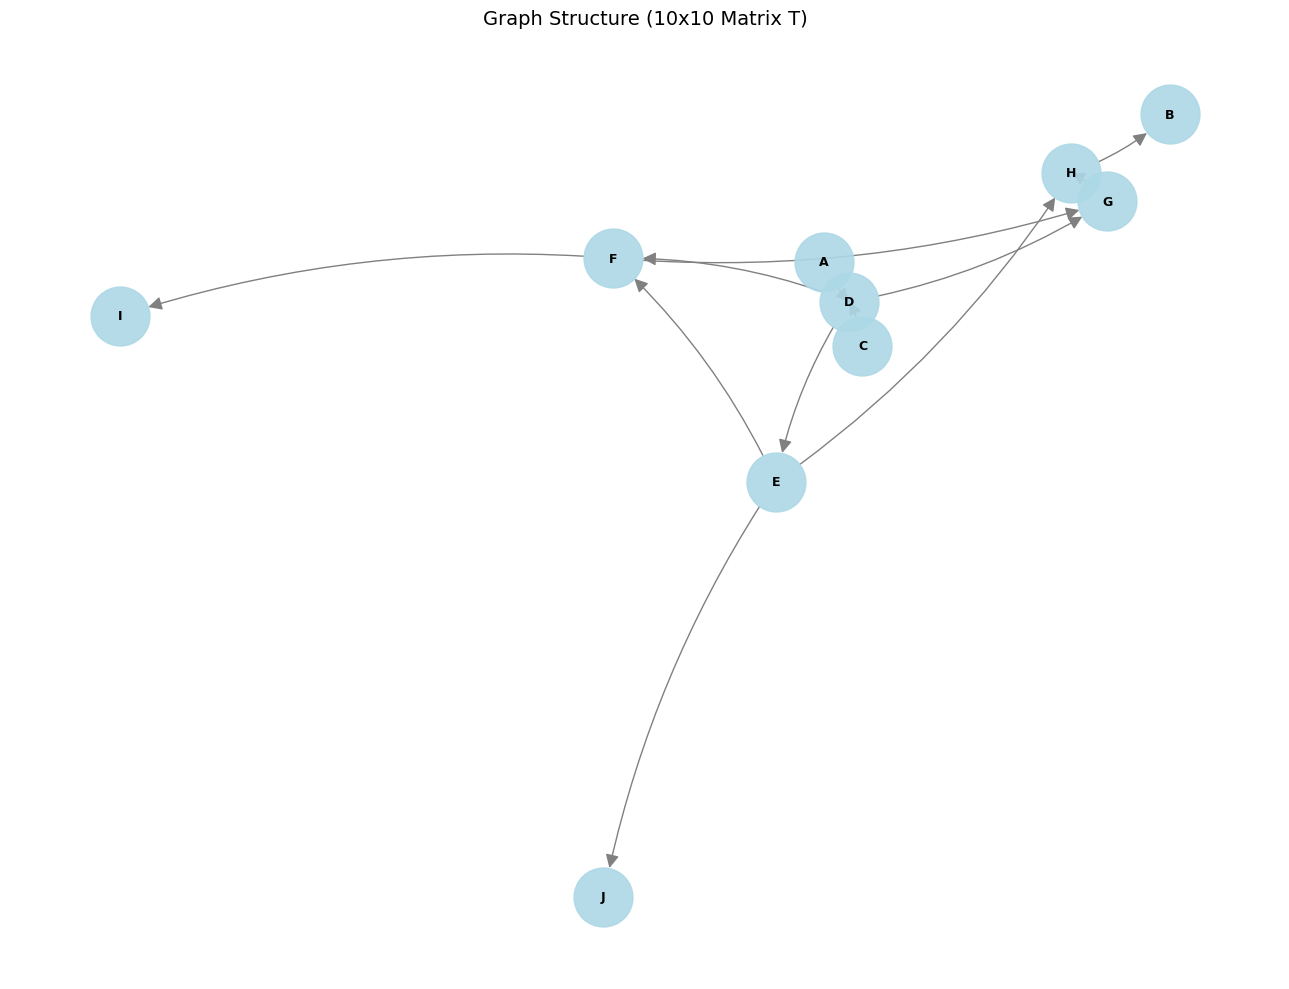

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import math

# --- REMOVE or COMMENT OUT this line ---
# matplotlib.use('Agg') # This prevents plt.show() from working in Colab/notebooks

# Labels
labels_10 = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
labels_4 = ['A', 'B', 'C', 'D']

def generate_contribution_matrix(size):
    """Generates one of the two example contribution matrices (T)."""
    if size == 4:
        t_matrix = np.array([
            [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0],
            [0.0, 2.0, 0.0, 0.0], [0.0, 2.0, 0.0, 0.0] ], dtype=float)
        return t_matrix
    elif size == 10:
        t_matrix = np.array([
            [0,0,0,1,0,0,0,0,0,0], [0,0,0,0,0,0,0,0,0,0], [0,0,0,3,0,0,0,0,0,0],
            [0,0,0,0,3,2,2,0,0,0], [0,0,0,0,0,2,0,2,0,1], [0,0,0,0,0,0,4,0,4,0],
            [0,0,0,0,0,0,0,3,0,0], [0,1,0,0,0,0,0,0,0,0], [0,0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,0]], dtype=float)
        return t_matrix
    else:
        print(f"Error: Size {size} not supported. Use 4 or 10.")
        return None

def visualize_graph_from_T_matrix(t_matrix, labels, title="Graph Structure", node_size=1500, font_size=10):
    """Visualizes the production graph using NetworkX and spring_layout."""
    n_nodes = t_matrix.shape[0]
    if len(labels) != n_nodes:
        print("Error: Number of labels does not match matrix size.")
        return

    print(f"\n--- Visualizing Graph: {title} (Using spring_layout) ---")

    G = nx.DiGraph()
    G.add_nodes_from(range(n_nodes))

    edge_list = []
    for j in range(n_nodes):
        for i in range(n_nodes):
            if t_matrix[j, i] > 0:
                edge_list.append((j, i))

    G.add_edges_from(edge_list)

    plt.figure(figsize=(13, 10))

    k_value = 0.8 / math.sqrt(n_nodes) if n_nodes > 0 else 0.8
    iterations_value = 75
    print(f"Using spring_layout with k={k_value:.3f}, iterations={iterations_value}")
    try:
        pos = nx.spring_layout(G, k=k_value, iterations=iterations_value, seed=42)
    except Exception as e:
        print(f"Error during spring_layout: {e}. Aborting plot.")
        plt.close()
        return

    if pos is None:
         print("Error: Could not determine node positions. Aborting plot.")
         return

    node_labels_dict = {i: labels[i] for i in range(n_nodes)}

    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color='lightblue', alpha=0.9)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=20, node_size=node_size, edge_color='gray', connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, labels=node_labels_dict, font_size=font_size, font_weight='bold')

    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    # plt.savefig(f"{title.replace(' ','_')}_spring.png") # Optionally save to file
    plt.show() # This should now display the plot in Colab

# --- Execution ---
if __name__ == "__main__":
    # Generate T matrices
    T_4 = generate_contribution_matrix(4)
    T_10 = generate_contribution_matrix(10)

    # Visualize 4x4
    if T_4 is not None:
        visualize_graph_from_T_matrix(T_4, labels_4, title="Graph Structure (4x4 Matrix T)")

    # Visualize 10x10
    if T_10 is not None:
        visualize_graph_from_T_matrix(T_10, labels_10, title="Graph Structure (10x10 Matrix T)", node_size=1800, font_size=9)


## Graph des attributs

### Propagation & Graphs bottum up


--- Preparing Data for Plots ---


--- Generating Combined Plot (4x4 Example) ---

--- Plotting Combined Chart: Combined Chart with Distance (4 Nodes) ---
Plotting Gantt Bars...
Plotting Cumulative Cost Curve...
Adding Cost labels...
Plotting Cumulative Mass Curve...
Adding Mass labels...
Plotting Cumulative Distance Curve...
Adding Distance labels...


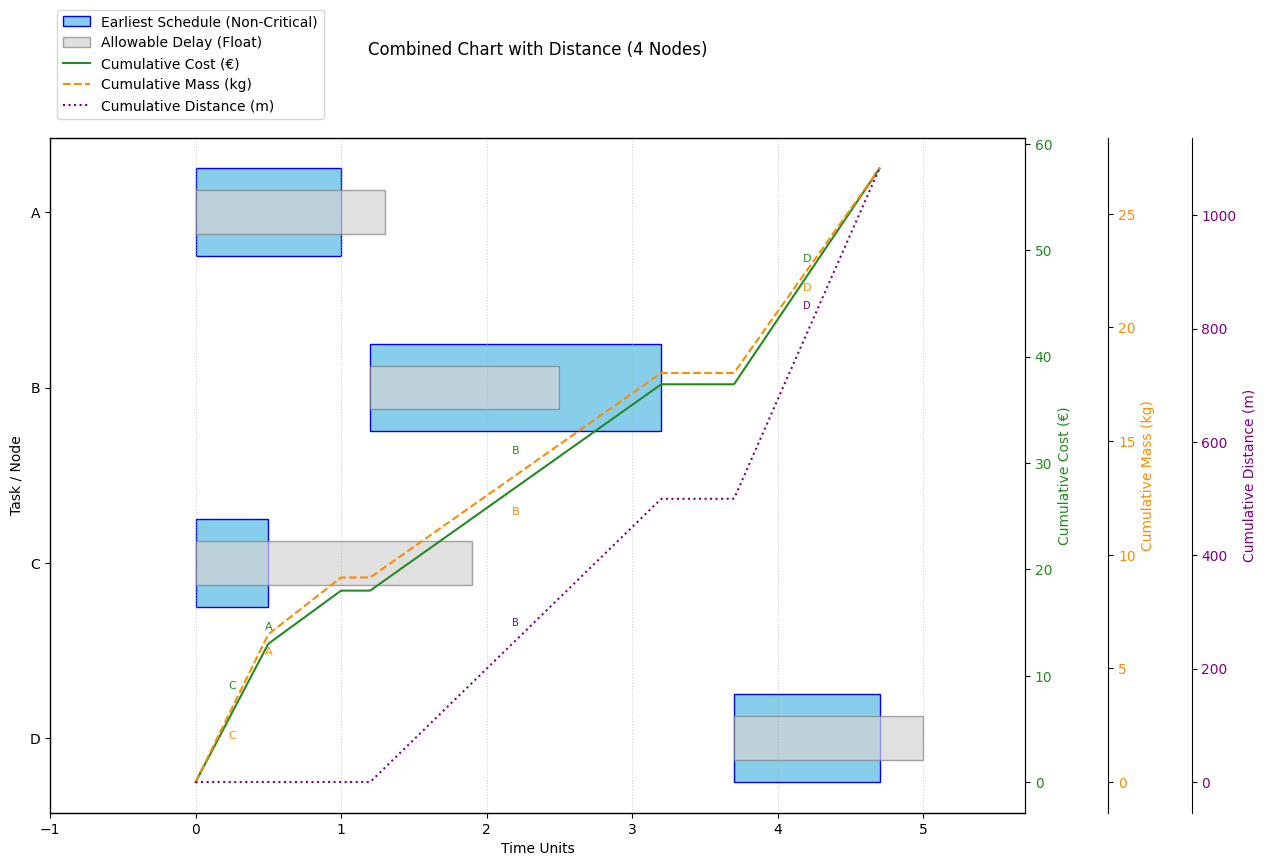


--- Generating Combined Plot (10x10 Example) ---

--- Plotting Combined Chart: Combined Chart with Distance (10 Nodes - Placeholder P) ---
Plotting Gantt Bars...
Plotting Cumulative Cost Curve...
Adding Cost labels...
Plotting Cumulative Mass Curve...
Adding Mass labels...
Plotting Cumulative Distance Curve...
Adding Distance labels...


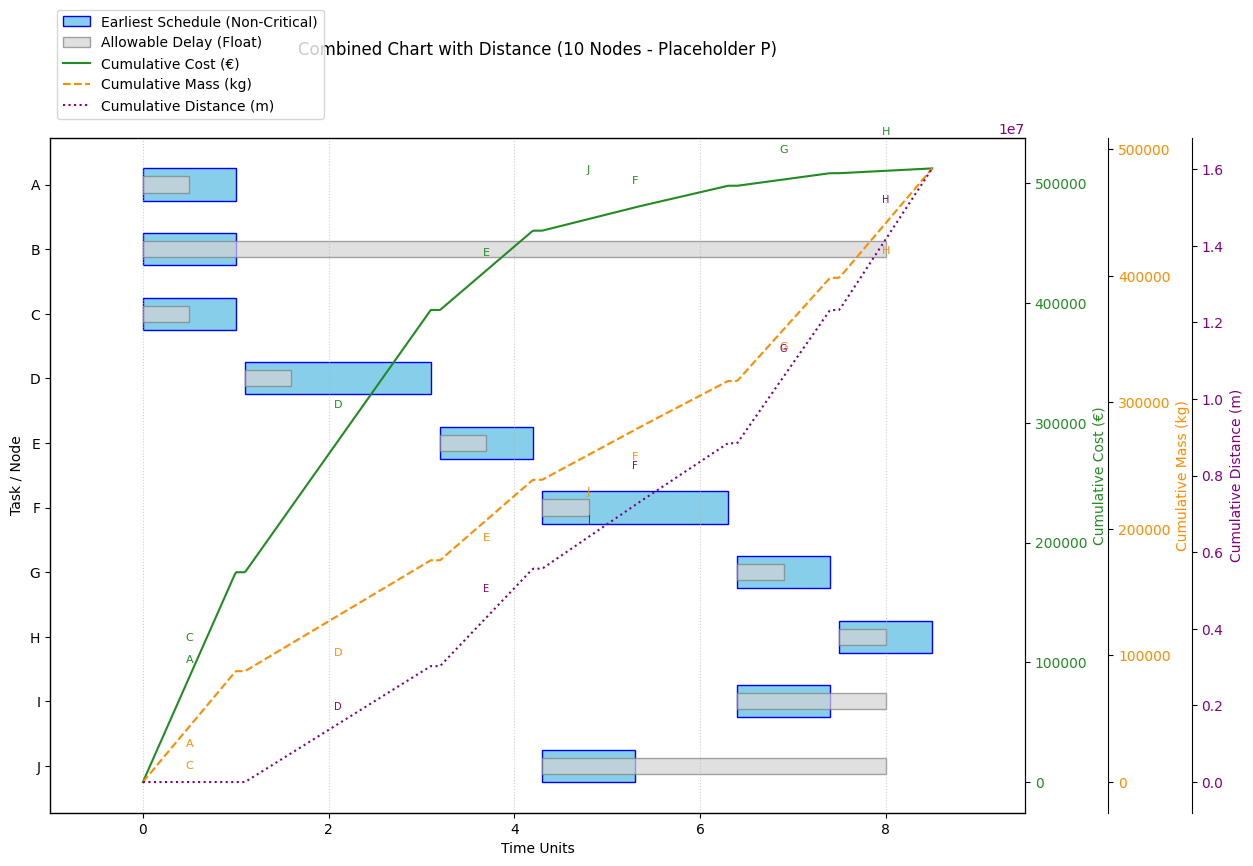

In [ ]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import math

# --- इंश्योर डिस्प्ले ---
# Ensure Agg backend is NOT used
# matplotlib.use('Agg') # <- Make sure this is commented out or removed

# --- Labels ---
labels_10 = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
labels_4 = ['A', 'B', 'C', 'D']

# --- Function Definitions (Copied from previous steps) ---

def generate_contribution_matrix(size):
    """Generates one of the two example contribution matrices (T)."""
    if size == 4:
        t_matrix = np.array([
            [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0],
            [0.0, 4.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0] ], dtype=float)
        return t_matrix
    elif size == 10:
        t_matrix = np.array([
            [0,0,0,1,0,0,0,0,0,0], [0,0,0,0,0,0,0,0,0,0], [0,0,0,3,0,0,0,0,0,0],
            [0,0,0,0,3,2,2,0,0,0], [0,0,0,0,0,2,0,2,0,1], [0,0,0,0,0,0,4,0,4,0],
            [0,0,0,0,0,0,0,3,0,0], [0,0,0,0,0,0,0,0,0,0], [0,0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,0]], dtype=float)
        return t_matrix
    else:
        # print(f"Erreur : Taille {size} non supportée. Veuillez utiliser 4 ou 10.")
        return None

def generate_node_coordinates(n_nodes, coord_range=(0, 100), seed=None):
    if seed is not None: np.random.seed(seed)
    coordinates = np.random.uniform(coord_range[0], coord_range[1], size=(n_nodes, 3))
    return coordinates

def calculate_transfer_distances(coordinates, t_matrix):
    n_nodes = coordinates.shape[0]
    if t_matrix.shape != (n_nodes, n_nodes): return None
    dist_matrix = np.zeros((n_nodes, n_nodes), dtype=float)
    for j in range(n_nodes):
        for i in range(n_nodes):
            if t_matrix[j, i] > 0:
                dist_matrix[j, i] = np.linalg.norm(coordinates[i] - coordinates[j])
    return dist_matrix

def calculate_propagated_value_iterative(base_value_vector, direct_value_matrix, t_matrix, max_iter_factor=1.2, verbose=False):
    n_comp = len(base_value_vector)
    if not (t_matrix.shape == (n_comp, n_comp) and direct_value_matrix.shape == (n_comp, n_comp)): return None
    max_iter = int(n_comp * max_iter_factor) + 1
    constant_term = np.zeros(n_comp)
    if np.array_equal(direct_value_matrix, np.zeros_like(direct_value_matrix)):
         constant_term = np.copy(base_value_vector)
    else:
         constant_term = np.sum(t_matrix * direct_value_matrix, axis=0)
    V_k = np.zeros(n_comp).reshape(1, n_comp)
    for k in range(max_iter):
        V_prev = np.copy(V_k)
        propagated_term = V_k @ t_matrix
        V_k = constant_term.reshape(1, n_comp) + propagated_term
        if np.allclose(V_k, V_prev): break
    else: print(f"Warning: Propagation for {n_comp} nodes might not have fully converged.")
    return V_k.flatten()

def calculate_total_quantities_corrected(final_demand_vector, t_matrix, max_iter_factor=1.2, verbose=False):
    """ Recalculates total quantities using Q_k+1 = Q_req + T @ Q_k """
    n_comp = len(final_demand_vector)
    if not (t_matrix.shape == (n_comp, n_comp)): return None
    max_iter = int(n_comp * max_iter_factor) + 1
    Q_req = final_demand_vector.reshape(-1, 1); Q_k = np.copy(Q_req)
    for k in range(max_iter):
        Q_prev = np.copy(Q_k)
        Intermediate_Needs = t_matrix @ Q_prev
        Q_k = Q_req + Intermediate_Needs
        if np.allclose(Q_k, Q_prev): break
    else: print("Warning: Quantity calculation might not have converged.")
    return Q_k.flatten()

def calculate_earliest_finish(node_delays_vec, transfer_delays_mat, adj_matrix_t, verbose=False):
    """ Recalculates EF times """
    n_nodes = len(node_delays_vec)
    if not (transfer_delays_mat.shape == (n_nodes, n_nodes) and adj_matrix_t.shape == (n_nodes, n_nodes)): return None
    EF = np.zeros(n_nodes)
    for k in range(n_nodes): # Iterate N times
        EF_prev = np.copy(EF)
        for i in range(n_nodes):
            predecessors = np.where(adj_matrix_t[i, :] == 1)[0]
            latest_arrival_time = 0.0
            if len(predecessors) > 0:
                arrival_times = [EF_prev[j] + transfer_delays_mat[j, i] for j in predecessors]
                latest_arrival_time = np.max(arrival_times) if arrival_times else 0.0
            ES_i = latest_arrival_time
            EF[i] = ES_i + node_delays_vec[i]
        if np.allclose(EF, EF_prev) and k>0 : break # Early exit if converged
    return EF

def calculate_latest_start(node_delays_vec, transfer_delays_mat, adj_matrix, deadline, verbose=False):
    """ Recalculates LS times """
    n_nodes = len(node_delays_vec)
    if not (transfer_delays_mat.shape == (n_nodes, n_nodes) and adj_matrix.shape == (n_nodes, n_nodes)): return None
    LS = np.full(n_nodes, np.inf); LF = np.full(n_nodes, np.inf)
    sink_nodes = np.where(np.sum(adj_matrix, axis=1) == 0)[0]
    LF[sink_nodes] = deadline
    for sn in sink_nodes: LS[sn] = LF[sn] - node_delays_vec[sn]
    current_LS = np.copy(LS)
    for k in range(n_nodes): # Iterate N times
        LS_prev_iter = np.copy(current_LS)
        for j in reversed(range(n_nodes)):
            if j in sink_nodes: continue
            successors = np.where(adj_matrix[j, :] == 1)[0]
            earliest_required_finish = np.inf
            if len(successors) > 0:
                required_arrival_times = [current_LS[i] - transfer_delays_mat[j, i] for i in successors]
                earliest_required_finish = np.min(required_arrival_times) if required_arrival_times else np.inf
            else: earliest_required_finish = LF[j] # Use pre-set deadline if no successors
            LF[j] = earliest_required_finish
            current_LS[j] = LF[j] - node_delays_vec[j]
        if np.allclose(current_LS, LS_prev_iter, equal_nan=True): break
    current_LS[np.isinf(current_LS)] = -999
    return current_LS

def calculate_cumulative_generic_linear(
    value_final, q_total, node_delays, ef_times,
    labels=None, verbose=False, num_time_points=500, value_name="Value"
):
    n_nodes = len(value_final)
    if labels and len(labels) != n_nodes: labels = None
    if not labels:
        if n_nodes == 4: labels = labels_4
        elif n_nodes == 10: labels = labels_10
        else: labels = [f"Node_{i}" for i in range(n_nodes)]
    es_times = ef_times - node_delays
    finite_ef = ef_times[np.isfinite(ef_times)]
    max_ef_time = np.max(finite_ef) if len(finite_ef)>0 else 1.0
    if max_ef_time <= 0: max_ef_time = 1.0
    activities = []
    for i in range(n_nodes):
        if (q_total[i] > 1e-9 and node_delays[i] > 1e-9 and
            np.isfinite(ef_times[i]) and np.isfinite(value_final[i])):
            start_time = es_times[i]; end_time = ef_times[i]
            total_value = value_final[i] * q_total[i]
            if np.isfinite(total_value) and abs(total_value) > 1e-9:
                activities.append({'label': labels[i], 'start': start_time, 'end': end_time, 'total_value': total_value})
    time_values = np.linspace(0, max_ef_time, num_time_points)
    if not np.isclose(time_values[0], 0.0): time_values = np.insert(time_values, 0, 0.0)
    if not np.isclose(time_values[-1], max_ef_time): time_values = np.append(time_values, max_ef_time)
    time_values = np.unique(time_values); num_time_points = len(time_values)
    cumulative_values = np.zeros_like(time_values)
    for k, t in enumerate(time_values):
        current_total_value = 0.0
        for act in activities:
            s, e, V, duration = act['start'], act['end'], act['total_value'], act['end'] - act['start']
            fraction = 0.0
            if math.isnan(s) or math.isnan(e): fraction = 0.0
            elif duration < 1e-9: fraction = 1.0 if t >= e else 0.0
            else: fraction = max(0, min(1, (t - s) / duration)) if t > s else 0.0
            if not math.isnan(V): current_total_value += V * fraction
        cumulative_values[k] = current_total_value
    return time_values, cumulative_values, activities

def plot_combined_schedule_cost_mass_distance( # Added Distance
    labels, node_delays, ef_times, ls_times,
    time_vals_cost, cum_costs_lin, activities_cost,
    time_vals_mass, cum_mass_lin, activities_mass,
    time_vals_dist, cum_dist_lin, activities_dist, # <<< NEW
    title="Combined Schedule, Cost, Mass, and Distance" # Updated Title
):
    n_nodes = len(labels)
    if not (len(node_delays)==n_nodes and len(ef_times)==n_nodes and len(ls_times)==n_nodes and
            time_vals_cost is not None and cum_costs_lin is not None and activities_cost is not None and
            time_vals_mass is not None and cum_mass_lin is not None and activities_mass is not None and
            time_vals_dist is not None and cum_dist_lin is not None and activities_dist is not None):
        print("Error: Missing or invalid input data for combined plot.")
        return
    print(f"\n--- Plotting Combined Chart: {title} ---")
    fig, ax1 = plt.subplots(figsize=(15, 9))
    # --- 1. Plot Gantt Chart (ax1) ---
    print("Plotting Gantt Bars...")
    es_times = ef_times - node_delays
    y_pos = np.arange(n_nodes)
    ax1.set_yticks(y_pos); ax1.set_yticklabels(labels); ax1.invert_yaxis()
    ax1.set_ylabel("Task / Node"); ax1.set_xlabel("Time Units")
    ax1.grid(axis='x', linestyle=':', alpha=0.6, which='major')
    legend_items = {}
    for i in range(n_nodes):
        es=es_times[i]; ef=ef_times[i]; ls=ls_times[i]; duration=node_delays[i]
        if math.isnan(es) or math.isnan(ef): continue
        plot_float = True
        if math.isnan(ls) or ls < es - 1e-6 or ls <= -999: task_float = 0; plot_float = False
        else: task_float = max(0, ls - es)
        bar_color='skyblue'; edge_color='blue'; crit_label='Earliest Schedule (Non-Critical)'
        if plot_float and np.isclose(task_float, 0): bar_color='salmon'; edge_color='red'; crit_label='Earliest Schedule (Critical Path)'
        bar = ax1.barh(y_pos[i], duration, left=es, height=0.5, align='center', color=bar_color, edgecolor=edge_color)
        if crit_label not in legend_items: legend_items[crit_label] = bar
        if plot_float and task_float > 1e-6:
             f_bar = ax1.barh(y_pos[i], task_float, left=es, height=0.25, align='center', color='lightgrey', edgecolor='grey', alpha=0.7)
             if 'Allowable Delay (Float)' not in legend_items: legend_items['Allowable Delay (Float)'] = f_bar
    # --- 2. Plot Cumulative Cost (ax2) ---
    print("Plotting Cumulative Cost Curve...")
    ax2 = ax1.twinx(); cost_color = 'forestgreen'
    line_cost, = ax2.plot(time_vals_cost, cum_costs_lin, color=cost_color, linestyle='-', label='Cumulative Cost (€)')
    ax2.set_ylabel("Cumulative Cost (€)", color=cost_color); ax2.tick_params(axis='y', labelcolor=cost_color)
    if line_cost.get_label() not in legend_items: legend_items[line_cost.get_label()] = line_cost
    cost_range_ax2 = np.max(cum_costs_lin) - np.min(cum_costs_lin); label_v_offset_ax2 = cost_range_ax2 * 0.02 if cost_range_ax2 > 0 else 1.5
    plotted_labels_cost = []; activities_cost.sort(key=lambda x: x['start'])
    print("Adding Cost labels...")
    for i, act in enumerate(activities_cost):
        s, e, label, duration = act['start'], act['end'], act['label'], act['end']-act['start']
        if math.isnan(s) or math.isnan(e) or duration < 1e-9: continue
        mid_t=(s+e)/2; mid_c=np.interp(mid_t, time_vals_cost, cum_costs_lin)
        if math.isnan(mid_c): continue
        current_offset = label_v_offset_ax2 * (1 + (i % 3) * 0.8); text_y = mid_c + current_offset
        for prev in plotted_labels_cost:
             if abs(text_y - prev['text_y']) < label_v_offset_ax2 * 1.2: current_offset += label_v_offset_ax2 * 1.0; text_y = mid_c + current_offset; break
        plotted_labels_cost.append({'text_y': text_y}); ax2.text(mid_t, text_y, label, ha='center', va='bottom', fontsize=8, color=cost_color, rotation=0)
    # --- 3. Plot Cumulative Mass (ax3) ---
    print("Plotting Cumulative Mass Curve...")
    ax3 = ax1.twinx(); ax3.spines['right'].set_position(('outward', 60)); mass_color = 'darkorange'
    line_mass, = ax3.plot(time_vals_mass, cum_mass_lin, color=mass_color, linestyle='--', label='Cumulative Mass (kg)')
    ax3.set_ylabel("Cumulative Mass (kg)", color=mass_color); ax3.tick_params(axis='y', labelcolor=mass_color)
    if line_mass.get_label() not in legend_items: legend_items[line_mass.get_label()] = line_mass
    mass_range_ax3 = np.max(cum_mass_lin) - np.min(cum_mass_lin); label_v_offset_ax3 = mass_range_ax3 * 0.02 if mass_range_ax3 > 0 else 1.5
    plotted_labels_mass = []; activities_mass.sort(key=lambda x: x['start'])
    print("Adding Mass labels...")
    for i, act in enumerate(activities_mass):
        s, e, label, duration = act['start'], act['end'], act['label'], act['end']-act['start']
        if math.isnan(s) or math.isnan(e) or duration < 1e-9: continue
        mid_t=(s+e)/2; mid_m=np.interp(mid_t, time_vals_mass, cum_mass_lin)
        if math.isnan(mid_m): continue
        current_offset = label_v_offset_ax3 * (1 + (i % 3) * 0.8); text_y = mid_m - current_offset # Below line
        for prev in plotted_labels_mass:
             if abs(text_y - prev['text_y']) < label_v_offset_ax3 * 1.2: current_offset += label_v_offset_ax3 * 1.0; text_y = mid_m - current_offset; break
        plotted_labels_mass.append({'text_y': text_y}); ax3.text(mid_t, text_y, label, ha='center', va='top', fontsize=8, color=mass_color, rotation=0)
    # --- 4. Plot Cumulative Distance (ax4) <<< NEW ---
    print("Plotting Cumulative Distance Curve...")
    ax4 = ax1.twinx(); ax4.spines['right'].set_position(('outward', 120)); dist_color = 'purple'
    line_dist, = ax4.plot(time_vals_dist, cum_dist_lin, color=dist_color, linestyle=':', label='Cumulative Distance (m)') # New style
    ax4.set_ylabel("Cumulative Distance (m)", color=dist_color); ax4.tick_params(axis='y', labelcolor=dist_color)
    if line_dist.get_label() not in legend_items: legend_items[line_dist.get_label()] = line_dist
    dist_range_ax4 = np.max(cum_dist_lin) - np.min(cum_dist_lin); label_v_offset_ax4 = dist_range_ax4 * 0.02 if dist_range_ax4 > 0 else 1.5
    plotted_labels_dist = []; activities_dist.sort(key=lambda x: x['start'])
    print("Adding Distance labels...")
    for i, act in enumerate(activities_dist):
        s, e, label, duration = act['start'], act['end'], act['label'], act['end']-act['start']
        if math.isnan(s) or math.isnan(e) or duration < 1e-9: continue
        mid_t=(s+e)/2; mid_d=np.interp(mid_t, time_vals_dist, cum_dist_lin)
        if math.isnan(mid_d): continue
        current_offset = label_v_offset_ax4 * (1 + (i % 3) * 0.9); text_y = mid_d + current_offset # Above line
        for prev in plotted_labels_dist:
             if abs(text_y - prev['text_y']) < label_v_offset_ax4 * 1.2: current_offset += label_v_offset_ax4 * 1.0; text_y = mid_d + current_offset; break
        plotted_labels_dist.append({'text_y': text_y}); ax4.text(mid_t, text_y, label, ha='center', va='bottom', fontsize=7, color=dist_color, rotation=0)
    # --- Final Touches ---
    finite_ef_times=ef_times[np.isfinite(ef_times)]; max_time_ef=np.max(finite_ef_times) if len(finite_ef_times)>0 else 0
    max_time_cost=np.max(time_vals_cost) if time_vals_cost is not None and len(time_vals_cost)>0 else 0
    max_time_mass=np.max(time_vals_mass) if time_vals_mass is not None and len(time_vals_mass)>0 else 0
    max_time_dist=np.max(time_vals_dist) if time_vals_dist is not None and len(time_vals_dist)>0 else 0
    max_time_all = max(max_time_ef, max_time_cost, max_time_mass, max_time_dist, 1.0)
    padding = max(1.0, max_time_all*0.05); ax1.set_xlim(-padding, max_time_all + padding)
    ax1.legend(legend_items.values(), legend_items.keys(), loc='upper left', bbox_to_anchor=(0, 1.20)) # Adjusted anchor
    ax1.set_title(title, pad=60) # Increased padding
    plt.subplots_adjust(left=0.1, right=0.75, top=0.85, bottom=0.1) # Adjust right margin
    plt.show()

# --- Example Usage ---
if __name__ == "__main__":
    # --- Common Setup ---
    print("\n--- Preparing Data for Plots ---")
    # 4x4 Data
    labels_4 = ['A', 'B', 'C', 'D']
    T_4 = generate_contribution_matrix(4)
    node_delays_4 = np.array([1.0, 2.0, 0.5, 1.0])
    Q_total_4 = np.array([1., 1., 4., 1.])
    transfer_delays_4 = np.array([[0, 0.2, 0, 0],[0, 0, 0, 0.5],[0, 0.1, 0, 0],[0, 0, 0, 0]], dtype=float)
    Adj_4 = (transfer_delays_4 > 0).astype(int); Adj_T_4 = Adj_4.T
    ef_times_4 = calculate_earliest_finish(node_delays_4, transfer_delays_4, Adj_T_4)
    ls_times_4 = calculate_latest_start(node_delays_4, transfer_delays_4, Adj_4, deadline=6.0)
    coords_4 = generate_node_coordinates(4, seed=42)
    dist_matrix_4 = calculate_transfer_distances(coords_4, T_4)
    M_base_4 = np.array([5., 0., 1., 0.])
    M_final_4 = calculate_propagated_value_iterative(M_base_4, np.zeros_like(T_4), T_4)
    DAPU_base_4 = np.zeros(4)
    DAPU_final_4 = calculate_propagated_value_iterative(DAPU_base_4, dist_matrix_4, T_4)
    P_final_4 = np.array([10.0, 19.4, 2.0, 20.3])
    time_vals_4_cost, cum_costs_lin_4, act_4_cost = calculate_cumulative_generic_linear(P_final_4, Q_total_4, node_delays_4, ef_times_4, labels_4, value_name="Cost")
    time_vals_4_mass, cum_mass_lin_4, act_4_mass = calculate_cumulative_generic_linear(M_final_4, Q_total_4, node_delays_4, ef_times_4, labels_4, value_name="Mass")
    time_vals_4_dist, cum_dist_lin_4, act_4_dist = calculate_cumulative_generic_linear(DAPU_final_4, Q_total_4, node_delays_4, ef_times_4, labels_4, value_name="Distance")

    # 10x10 Data
    labels_10 = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
    T_10 = generate_contribution_matrix(10)
    node_delays_10 = np.array([1.0, 1.0, 1.0, 2.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0])
    Q_req_10 = np.zeros(10); Q_req_10[7]=100.0; Q_req_10[9]=50.0 # H=100, J=50
    Q_total_10 = calculate_total_quantities_corrected(Q_req_10, T_10)
    transfer_delays_10 = (T_10 > 0).astype(float) * 0.1 # Example transfer delays
    Adj_10 = (transfer_delays_10 > 0).astype(int); Adj_T_10 = Adj_10.T
    ef_times_10 = calculate_earliest_finish(node_delays_10, transfer_delays_10, Adj_T_10)
    ls_times_10 = calculate_latest_start(node_delays_10, transfer_delays_10, Adj_10, deadline=9.0) # Adjusted deadline slightly > max EF
    coords_10 = generate_node_coordinates(10, seed=123)
    dist_matrix_10 = calculate_transfer_distances(coords_10, T_10)
    M_base_10 = np.array([5., 1., 1., 0., 0., 0., 0., 0., 0., 0.]) # Example base mass
    M_final_10 = calculate_propagated_value_iterative(M_base_10, np.zeros_like(T_10), T_10)
    DAPU_base_10 = np.zeros(10)
    DAPU_final_10 = calculate_propagated_value_iterative(DAPU_base_10, dist_matrix_10, T_10)
    P_final_10_ph = np.array([10, 19, 2, 20, 25, 30, 35, 40, 38, 30]) # Placeholder prices
    print("\nWARNING: Using PLACEHOLDER P_final for 10x10 Calculation!")
    time_vals_10_cost, cum_costs_lin_10, act_10_cost = calculate_cumulative_generic_linear(P_final_10_ph, Q_total_10, node_delays_10, ef_times_10, labels_10, value_name="Cost")
    time_vals_10_mass, cum_mass_lin_10, act_10_mass = calculate_cumulative_generic_linear(M_final_10, Q_total_10, node_delays_10, ef_times_10, labels_10, value_name="Mass")
    time_vals_10_dist, cum_dist_lin_10, act_10_dist = calculate_cumulative_generic_linear(DAPU_final_10, Q_total_10, node_delays_10, ef_times_10, labels_10, value_name="Distance")


    # --- Plotting ---
    print("\n--- Generating Combined Plot (4x4 Example) ---")
    plot_combined_schedule_cost_mass_distance(
        labels=labels_4, node_delays=node_delays_4, ef_times=ef_times_4, ls_times=ls_times_4,
        time_vals_cost=time_vals_4_cost, cum_costs_lin=cum_costs_lin_4, activities_cost=act_4_cost,
        time_vals_mass=time_vals_4_mass, cum_mass_lin=cum_mass_lin_4, activities_mass=act_4_mass,
        time_vals_dist=time_vals_4_dist, cum_dist_lin=cum_dist_lin_4, activities_dist=act_4_dist,
        title="Combined Chart with Distance (4 Nodes)"
    )

    print("\n--- Generating Combined Plot (10x10 Example) ---")
    plot_combined_schedule_cost_mass_distance(
        labels=labels_10, node_delays=node_delays_10, ef_times=ef_times_10, ls_times=ls_times_10,
        time_vals_cost=time_vals_10_cost, cum_costs_lin=cum_costs_lin_10, activities_cost=act_10_cost,
        time_vals_mass=time_vals_10_mass, cum_mass_lin=cum_mass_lin_10, activities_mass=act_10_mass,
        time_vals_dist=time_vals_10_dist, cum_dist_lin=cum_dist_lin_10, activities_dist=act_10_dist,
        title="Combined Chart with Distance (10 Nodes - Placeholder P)"
    )


L'exemple ci-dessous reprend vos données (matrice T, noms des nœuds, etc.), les sauvegarde dans un groupe Zarr sur un bucket GCS, puis les recharge pour vérifier que l'opération a réussi.

-----

### Prérequis

Pour que ce code fonctionne, vous devez d'abord installer les bibliothèques nécessaires et vous authentifier auprès de Google Cloud.

1.  **Installation des bibliothèques** :
    ```bash
    pip install zarr gcsfs numpy
    ```
2.  **Authentification Google Cloud** :
    La bibliothèque `gcsfs` cherchera automatiquement vos identifiants Google Cloud. Le plus simple est de vous connecter via le SDK Google Cloud sur votre machine :
    ```bash
    gcloud auth application-default login
    ```

-----

### Code : Sauvegarde et Lecture avec Zarr sur GCS